## Performing Exploratory Data Analysis (EDA)

In [ ]:
%pip install numpy pandas matplotlib seaborn
%pip install plotly scipy

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)

# Load the data
df = pd.read_csv("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/data/processed/aqi_cleaned.csv", parse_dates=['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['Season'] = df['Date'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring', 
    6: ' Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Monsoon', 11: 'Monsoon'
})

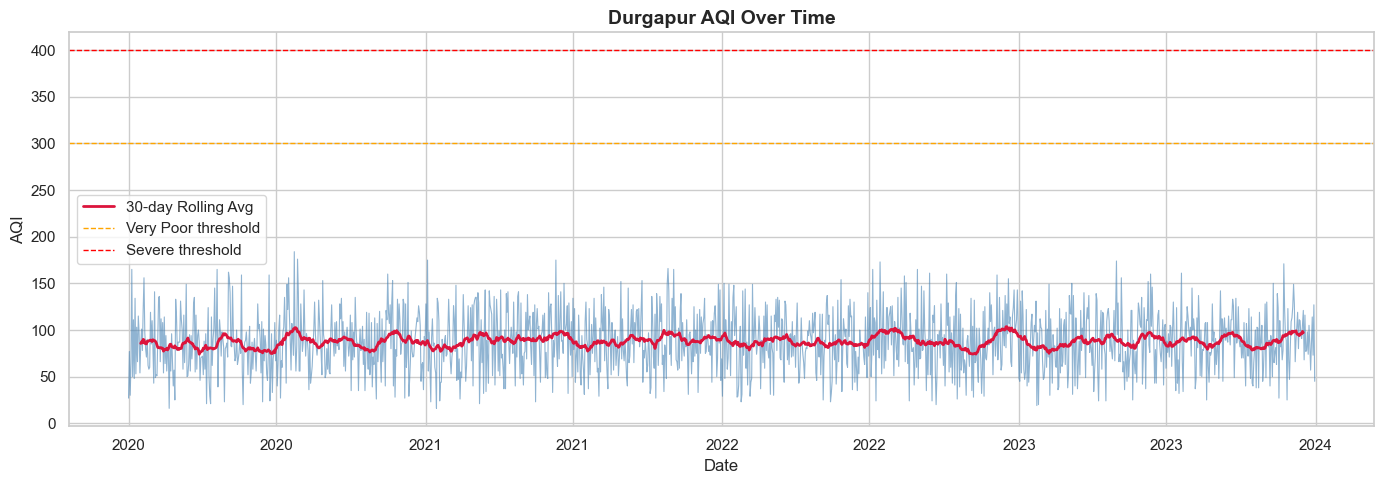

In [ ]:
# ── PLOT 1: AQI over time ─────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(df['Date'], df['aqi'], color='steelblue', linewidth=0.8, alpha=0.6)

# 30-day rolling average
rolling = df['aqi'].rolling(window=30, center=True).mean()
ax.plot(df['Date'], rolling, color='crimson', linewidth=2, label='30-day Rolling Avg')

ax.axhline(300, color='orange', linestyle='--', linewidth=1, label='Very Poor threshold')
ax.axhline(400, color='red', linestyle='--', linewidth=1, label='Severe threshold')
ax.set_title("Durgapur AQI Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/reports/aqi_timeseries.png", dpi=150)
plt.show()

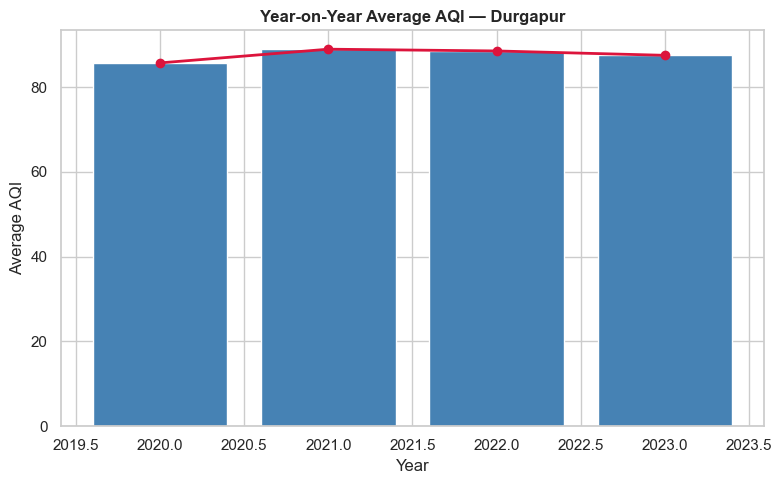

In [15]:
# ── PLOT 2: Year-on-Year Average AQI (Trend) ─────────────────────
yearly = df.groupby('Year')['aqi'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(yearly['Year'], yearly['aqi'], color='steelblue', edgecolor='white')
ax.plot(yearly['Year'], yearly['aqi'], color='crimson', marker='o', linewidth=2)
ax.set_title("Year-on-Year Average AQI — Durgapur", fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.savefig("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/reports/aqi_yaerly_trend.png", dpi=150)
plt.show()

C:\Users\Rahul Nag\AppData\Local\Temp\ipykernel_5232\1753016795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MonthName', y='aqi', order=month_order,


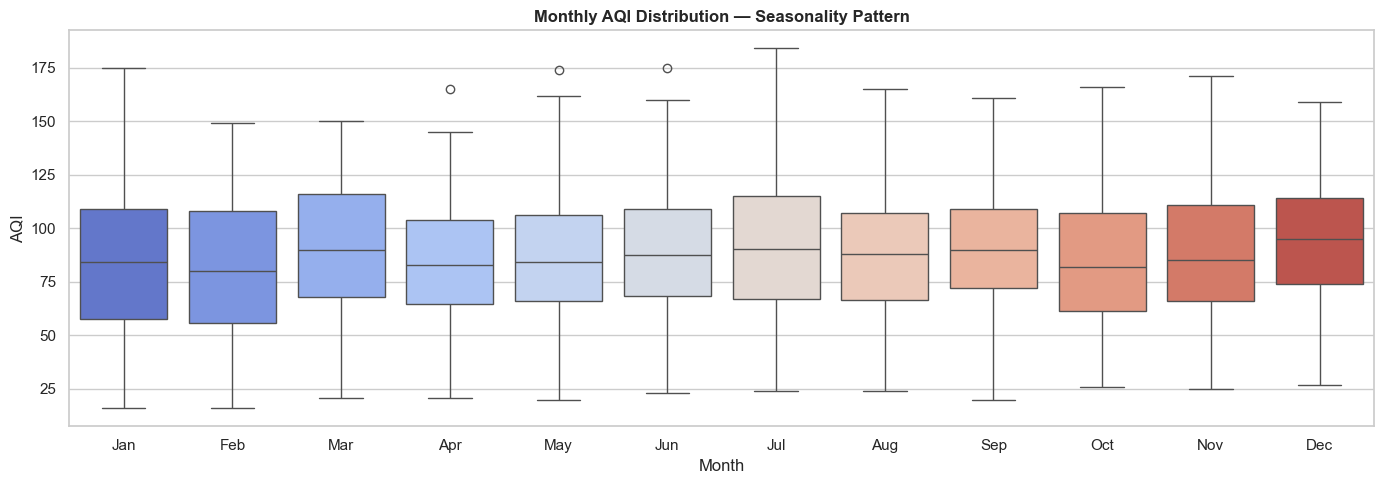

In [22]:
# ── PLOT 3: Monthly Seasonality (Boxplot) ────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df, x='MonthName', y='aqi', order=month_order,
            palette='coolwarm', ax=ax)
ax.set_title("Monthly AQI Distribution — Seasonality Pattern", fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.savefig("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/reports/aqi_monthly_boxplot.png")
plt.show()

In [29]:
# ── PLOT 4: AQI Category Pie Chart ───────────────────────────────
category_counts = df['AQI_Category'].value_counts()
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50']
category_colors = dict(zip(
    ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe'], colors))

fig = px.pie(
    names=category_counts.index,
    values=category_counts.values,
    title="AQI Category Distribution — Durgapur",
    color=category_counts.index,
    color_discrete_map=category_colors
)
fig.write_html("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/reports/aqi_category_pie.html")
fig.show()

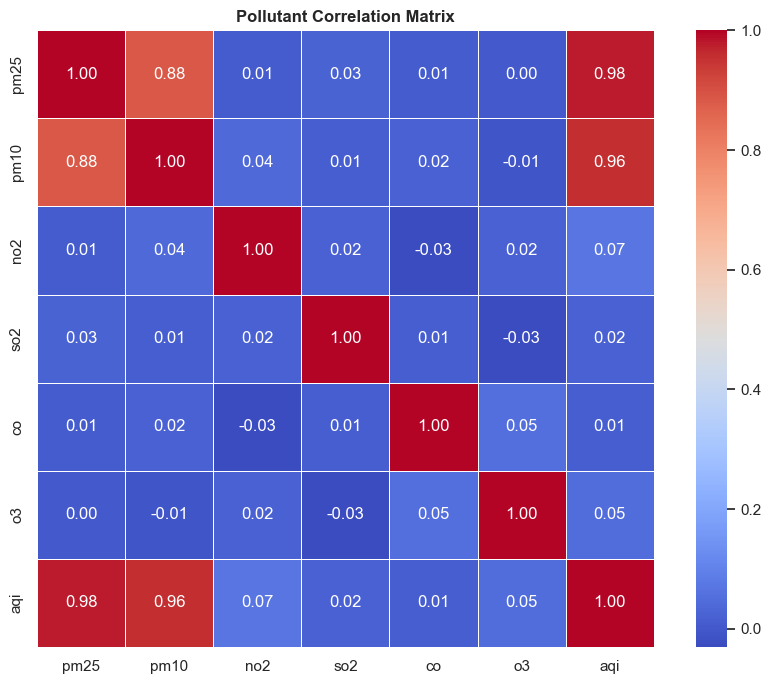

In [36]:
# ── PLOT 5: Correlation Heatmap (Pollutants) ─────────────────────
numeric_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi']
available_cols = [c for c in numeric_cols if c in df.columns]

corr = df[available_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Pollutant Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/reports/pollution-correlation.png", dpi=150)
plt.show()

In [37]:
# ── STAT: Mann-Kendall Trend Test ─────────────────────────────────
# Simple linear trend as proxy
slope, intercept, r, p, se = stats.linregress(
    range(len(df['aqi'].dropna())), df['aqi'].dropna())
print(f"\n=== Trend Analysis ===")
print(f"AQI Slope: {slope:.4f} per day")
print(f"Direction: {'WORSENING ↑' if slope > 0 else 'IMPROVING ↓'}")
print(f"p-value: {p:.4f} ({'Statistically significant' if p < 0.05 else 'Not significant'})")


=== Trend Analysis ===
AQI Slope: 0.0023 per day
Direction: WORSENING ↑
p-value: 0.2393 (Not significant)
